In [290]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [291]:
# Load data
presence = pd.read_csv('src/data/trajectories.csv')
presence.head(3)

,scientific_name,longitude,latitude,year,month
0,Phoebastria immutabilis,-120.661335,28.619472,2014,2
1,Phoebastria immutabilis,-116.502582,29.688723,2014,3
2,Phoebastria immutabilis,-118.291728,28.884567,2014,1


In [292]:
background = pd.read_csv('src/data/backgound_points.csv')
background.head(5)

,longitude,latitude,rand_point_id,class,area_exten
0,-145.672040,13.548375,0,0,background
1,-131.554414,25.889406,1,0,background
2,-156.454840,47.053826,2,0,background
3,-142.677073,16.932239,3,0,background
4,-148.790676,35.224533,4,0,background


In [293]:
import geopandas as gpd

geo_df = gpd.GeoDataFrame(background, geometry=gpd.points_from_xy(background['longitude'], background['latitude']))
geo_df.crs = {'init': 'epsg:4326'}
geo_df.head(5)

,longitude,latitude,rand_point_id,class,area_exten,geometry
0,-145.672040,13.548375,0,0,background,POINT (-145.67204 13.54838)
1,-131.554414,25.889406,1,0,background,POINT (-131.55441 25.88941)
2,-156.454840,47.053826,2,0,background,POINT (-156.45484 47.05383)
3,-142.677073,16.932239,3,0,background,POINT (-142.67707 16.93224)
4,-148.790676,35.224533,4,0,background,POINT (-148.79068 35.22453)


In [294]:
presence_geo = gpd.GeoDataFrame(presence, geometry=gpd.points_from_xy(presence['longitude'], presence['latitude']))
presence_geo.crs = {'init': 'epsg:4326'}
presence_geo.head(5)

,scientific_name,longitude,latitude,year,month,geometry
0,Phoebastria immutabilis,-120.661335,28.619472,2014,2,POINT (-120.66133 28.61947)
1,Phoebastria immutabilis,-116.502582,29.688723,2014,3,POINT (-116.50258 29.68872)
2,Phoebastria immutabilis,-118.291728,28.884567,2014,1,POINT (-118.29173 28.88457)
3,Phoebastria immutabilis,-116.570818,30.835675,2014,3,POINT (-116.57082 30.83567)
4,Phoebastria immutabilis,-125.357577,40.855175,2014,3,POINT (-125.35758 40.85518)


(9999, 6)


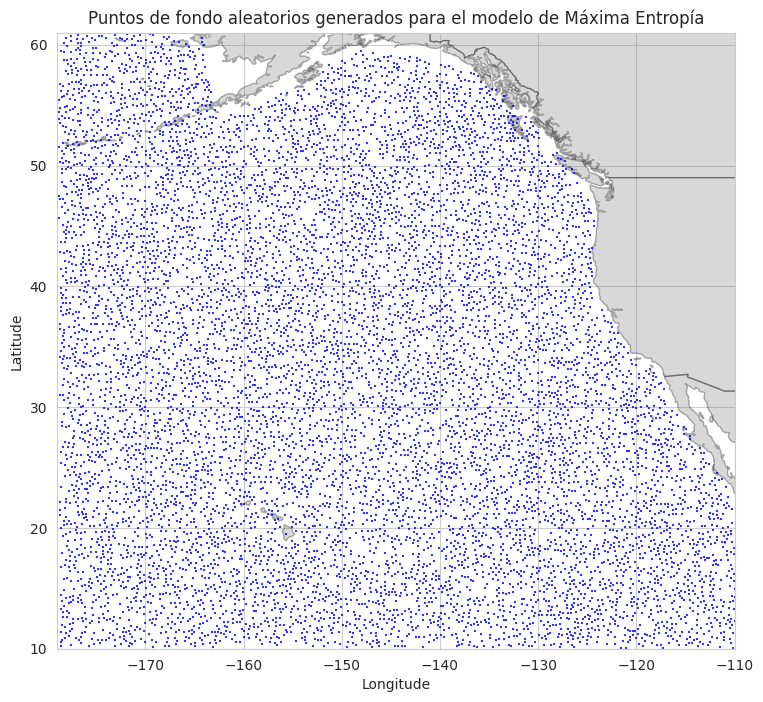

In [305]:
# Mapa de la zona de estudio
import matplotlib.pyplot as plt
from shapely import wkt

shapefile_name = 'src/data/americas_shapefile.csv'
# Load shapefile from csv
shp_df = pd.read_csv(shapefile_name)

shapefile = gpd.GeoDataFrame(shp_df, geometry=shp_df['geom'].apply(wkt.loads))

base = shapefile.plot(figsize=(12, 8), alpha=0.3, edgecolor='k', color='gray')
geo_df.plot(ax=base, alpha=0.8, marker='+', markersize=3, color='blue')
#presence_geo.plot(ax=base, alpha=0.5, marker='o', markersize=1, color='green')
print(geo_df.shape)

# Ejes
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Título
plt.title('Puntos de fondo aleatorios generados para el modelo de Máxima Entropía')

# Zoom in to see the trajectories

min_lat = 10
max_lat = 61
min_lon = -179
max_lon = -110

plt.xlim(min_lon, max_lon)
plt.ylim(min_lat, max_lat)
plt.show()

In [296]:
# Análisis exploratorio de los datos integrados

annots = pd.read_csv('src/data/annotated_1.csv')
annots.sample(5)

,longitude,latitude,geometry,class,easward_wind,norward_wind,sst,chla,year,month
51987,-119.238037,28.108290,POINT (-119.238037 28.10829),1,19,-463,18.916643,0.070059,2018,1
18853,-132.418124,27.965578,POINT (-132.418123548444 27.9655784671779),0,-459,-8,19.061850,0.072929,2014,1
59035,-156.887894,30.098553,POINT (-156.88789357622 30.0985525751283),0,138,271,19.484045,0.113094,2018,1
4769,-124.365453,30.324357,POINT (-124.365453 30.324357),1,-92,-463,16.868788,0.098929,2014,1
22699,-171.421923,17.673673,POINT (-171.421923049958 17.6736726265753),0,-457,-189,26.262825,0.042801,2014,1


In [297]:
print('Cantidad de puntos por clase  \n', annots['class'].value_counts())
# Subselect presence data
presence = annots[annots['class'] == 1]
presence.sample(5)
print('Cantidad de puntos de presencia \n', presence['class'].value_counts())

Cantidad de puntos por clase  
 class
1    37772
0    26426
Name: count, dtype: int64
Cantidad de puntos de presencia 
 class
1    37772
Name: count, dtype: int64


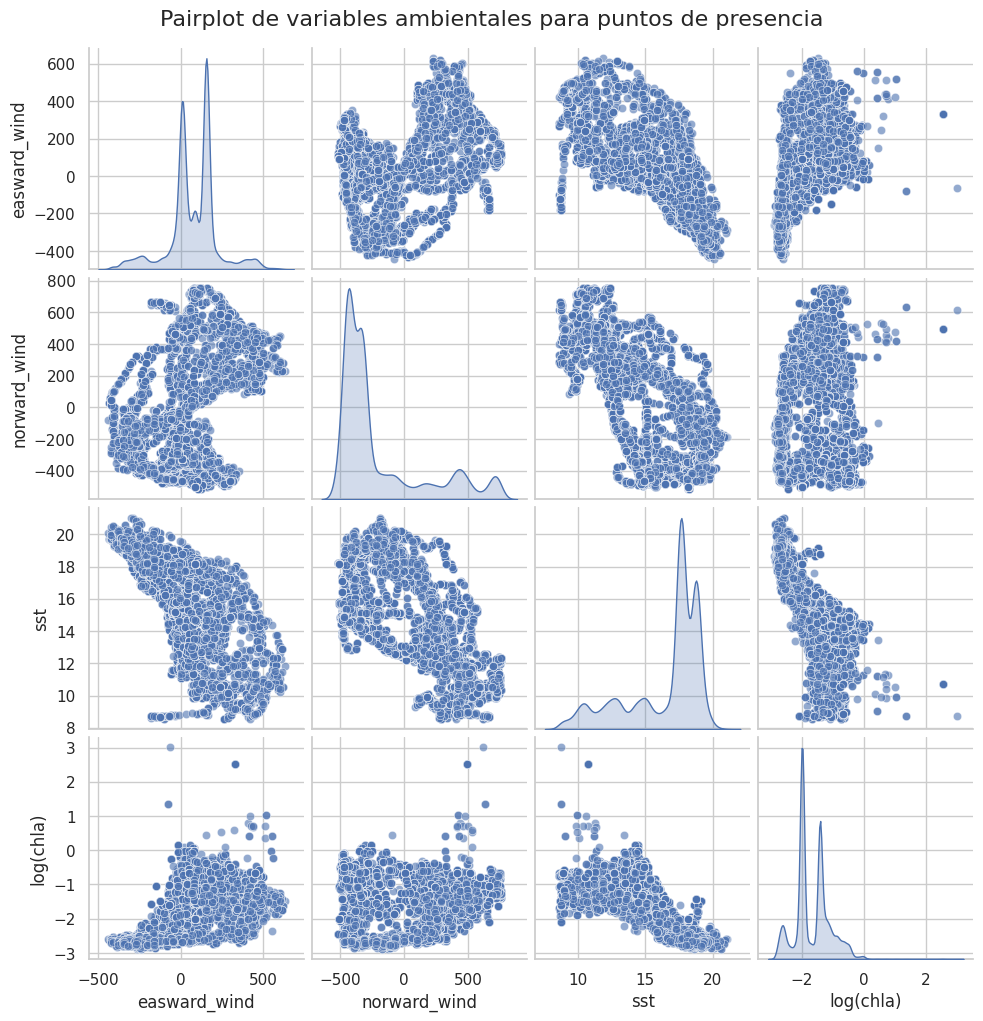

In [318]:
import numpy as np

variables_ambientales_pairplot = presence[['easward_wind', 'norward_wind', 'sst', 'chla']]
# Pairplot de las variables ambientales
epsilon = 1e-10
variables_ambientales_pairplot['log_chla'] = np.log(variables_ambientales_pairplot['chla'] + epsilon)

# Seleccionar las variables ambientales incluyendo la `chla` logarítmica
variables_ambientales_log = variables_ambientales_pairplot[['easward_wind', 'norward_wind', 'sst', 'log_chla']]

# Crear el pairplot
sns.set_theme(style="whitegrid")
pairplot = sns.pairplot(variables_ambientales_log, diag_kind='kde', plot_kws={'alpha': 0.6})

# Ajustar etiquetas para la variable logarítmica
pairplot.figure.suptitle('Pairplot de variables ambientales para puntos de presencia', fontsize=16, y=1.02)

for ax in pairplot.axes.flatten():
    if ax.get_xlabel() == 'log_chla':
        ax.set_xlabel('log(chla)')
    elif ax.get_xlabel():
        ax.set_xlabel(ax.get_xlabel())
        
    if ax.get_ylabel() == 'log_chla':
        ax.set_ylabel('log(chla)')
    elif ax.get_ylabel():
        ax.set_ylabel(ax.get_ylabel())

plt.show()

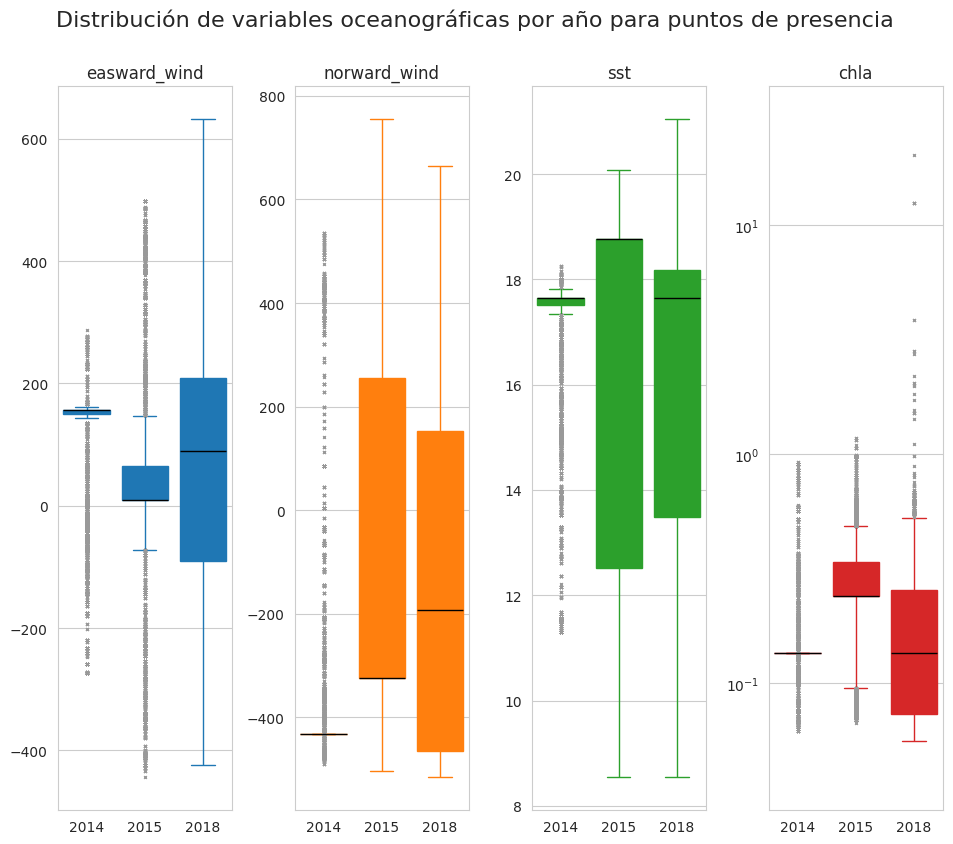

In [299]:
variables_ambientales = presence[['easward_wind', 'norward_wind', 'sst', 'chla', 'year']]

# Configurar las propiedades del flier (outliers)
flierprops = dict(marker='x', color='red', markersize=2)

# Configurar el tamaño de los gráficos
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")


# Definir los colores sólidos para cada variable
colors = {
    'easward_wind': '#1f77b4',  # Azul
    'norward_wind': '#ff7f0e',  # Naranja
    'sst': '#2ca02c',           # Verde
    'chla': '#d62728'           # Rojo
}

# Crear gráficos de caja y bigotes para cada variable
for i, col in enumerate(variables_ambientales.columns[:-1], 1):
    plt.subplot(1, len(variables_ambientales.columns), i)
    
    # Seleccionar el color de la caja
    box_color = colors.get(col, 'black')  # Si la variable no está en el dict, usar negro por defecto
    
    sns.boxplot(
        data= variables_ambientales,
        x=variables_ambientales['year'],
        y=variables_ambientales[col], 
        flierprops=flierprops,
        color='white',
        boxprops=dict(facecolor=box_color, edgecolor=box_color), 
        whiskerprops=dict(color=box_color),
        capprops=dict(color=box_color),
        medianprops=dict(color='black')  # La mediana se muestra en negro para contraste
    )
    plt.title(col)
    
    # Aplicar escala logarítmica a chla
    if col == 'chla':
        plt.yscale('log')
        plt.ylim(variables_ambientales[col].min() * 0.5, variables_ambientales[col].max() * 2)
    
    plt.ylabel('')
    plt.xlabel('')

plt.tight_layout()
plt.suptitle('Distribución de variables oceanográficas por año para puntos de presencia', fontsize=16, x=0.4, y=1.05)
plt.show()

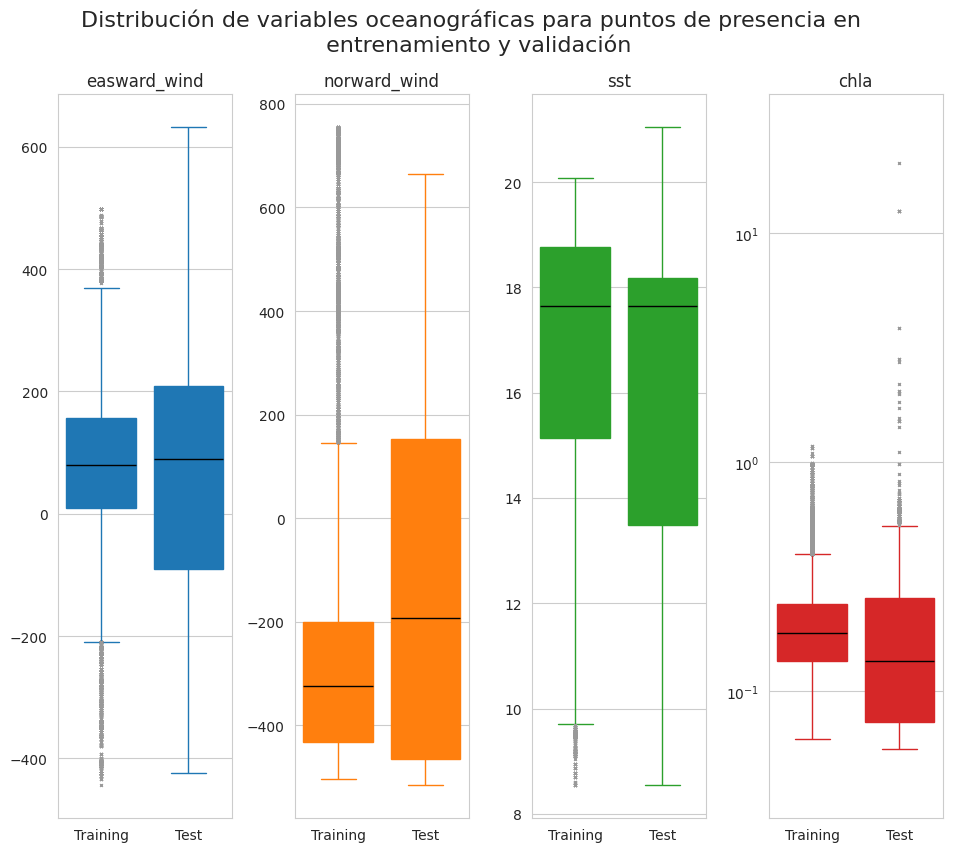

In [301]:
# Seleccionar las variables ambientales
variables_train_test = presence[['easward_wind', 'norward_wind', 'sst', 'chla', 'year']]

# Agrupar los años < 2018 en una categoría 'Antes de 2018'
variables_train_test['year_group'] = variables_ambientales['year'].apply(lambda x: 'Training' if x < 2018 else 'Test')

# Seleccionar las variables ambientales junto con el grupo de año
variables_train_test = variables_train_test[['easward_wind', 'norward_wind', 'sst', 'chla', 'year_group']]

# Configurar el tamaño de los gráficos
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")


# Definir los colores sólidos para cada variable
colors = {
    'easward_wind': '#1f77b4',  # Azul
    'norward_wind': '#ff7f0e',  # Naranja
    'sst': '#2ca02c',           # Verde
    'chla': '#d62728'           # Rojo
}

# Crear gráficos de caja y bigotes para cada variable
for i, col in enumerate(variables_train_test.columns[:-1], 1):
    plt.subplot(1, len(variables_train_test.columns), i)
    
    # Seleccionar el color de la caja
    box_color = colors.get(col, 'black')  # Si la variable no está en el dict, usar negro por defecto
    
    sns.boxplot(
        data=variables_train_test,
        x=variables_train_test['year_group'],
        y=variables_train_test[col], 
        flierprops=flierprops,
        color='white',
        boxprops=dict(facecolor=box_color, edgecolor=box_color), 
        whiskerprops=dict(color=box_color),
        capprops=dict(color=box_color),
        medianprops=dict(color='black')  # La mediana se muestra en negro para contraste
    )
    plt.title(col)
    
    # Aplicar escala logarítmica a chla
    if col == 'chla':
        plt.yscale('log')
        plt.ylim(variables_train_test[col].min() * 0.5, variables_train_test[col].max() * 2)
    
    plt.ylabel('')
    plt.xlabel('')

plt.tight_layout()
plt.suptitle('Distribución de variables oceanográficas para puntos de presencia en \n entrenamiento y validación', fontsize=16, x= 0.4, y=1.06)
plt.show()